In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt
import os

from pre_processing import processed_img_preview, img_processing


In [2]:
IMAGE_PATH = "./dataset/word2.png"
OUTPUT_DIR = "segmented_letters"
IMG_SIZE = 128

os.makedirs(OUTPUT_DIR, exist_ok=True)


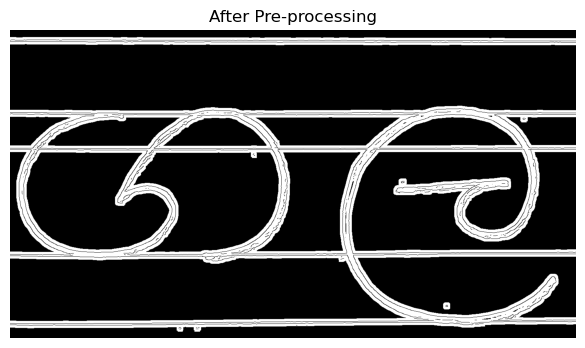

In [3]:
img = cv2.imread(IMAGE_PATH)

if img is None:
    raise ValueError("Image not found")

clean = img_processing(img)

plt.figure(figsize=(8,4))
plt.imshow(clean, cmap="gray")
plt.title("After Pre-processing")
plt.axis("off")
plt.show()


In [ ]:
# Function to create a version of the image for projection where horizontal ruling lines are suppressed
def projection_image_ignore_lines(img):
    """
    Create a version ONLY for projection where
    horizontal ruling lines are suppressed.
    Original image is untouched.
    """
    kernel = cv2.getStructuringElement(cv2.MORPH_RECT, (1, 25))
    vertical_strokes = cv2.morphologyEx(img, cv2.MORPH_OPEN, kernel)
    return vertical_strokes

In [ ]:
# Function to refine the split column by searching for a nearby column with fewer ink pixels
def refine_split_column(img, col, search_radius=8):
    h, w = img.shape
    start = max(col - search_radius, 1)
    end   = min(col + search_radius, w - 1)

    ink_counts = [
        np.sum(img[:, c] == 255)
        for c in range(start, end)
    ]

    return start + np.argmin(ink_counts)

In [ ]:
# Function to split the word into letters without cropping
def split_word_exact_no_crop(
    binary_img,
    num_letters,
    smooth_window=21,
):
    img = binary_img.copy()
    h, w = img.shape

    # --- build projection image ---
    proj_img = projection_image_ignore_lines(img)
    projection = np.sum(proj_img == 255, axis=0)

    kernel = np.ones(smooth_window) / smooth_window
    projection = np.convolve(projection, kernel, mode="same")

    # --- find valleys ---
    max_val = np.max(projection)
    valley_cols = np.where(projection < 0.5 * max_val)[0]

    if len(valley_cols) == 0:
        return [img]

    # group continuous valleys
    groups = np.split(
        valley_cols,
        np.where(np.diff(valley_cols) != 1)[0] + 1
    )

    centers = [int(g.mean()) for g in groups]

    # choose most balanced valleys
    centers = sorted(
        centers,
        key=lambda c: abs((w - c) - c)
    )

    splits = sorted(centers[: num_letters - 1])

    # refine splits
    splits = [refine_split_column(img, s) for s in splits]

    # --- split ONLY by columns ---
    letters = []
    prev = 0

    for s in splits:
        letters.append(img[:, prev:s])
        prev = s

    letters.append(img[:, prev:])

    # safety merge
    while len(letters) > num_letters:
        a = letters.pop(-2)
        b = letters.pop(-1)
        letters.append(np.hstack([a, b]))

    return letters

In [ ]:
# Function to preview the split letters (NO CROPPING)
def preview_no_crop(binary_img, num_letters):
    letters = split_word_exact_no_crop(binary_img, num_letters)

    plt.figure(figsize=(15, 3))
    for i, l in enumerate(letters):
        plt.subplot(1, len(letters), i + 1)
        plt.imshow(l, cmap="gray")
        plt.axis("off")

    plt.suptitle(
        f"Split into {len(letters)} letters (target = {num_letters}) — NO CROP"
    )
    plt.show()

    return letters

In [ ]:
# Function to save segmented letters
def save_letters(
    letters,
    base_dir="output_letters",
    prefix="letter",
    ext=".png"
):

    os.makedirs(base_dir, exist_ok=True)

    for i, img in enumerate(letters):
        filename = f"{prefix}_{i+1}{ext}"
        path = os.path.join(base_dir, filename)

        # Ensure uint8
        img_to_save = img.astype("uint8")

        cv2.imwrite(path, img_to_save)

    print(f"Saved {len(letters)} images to '{base_dir}'")

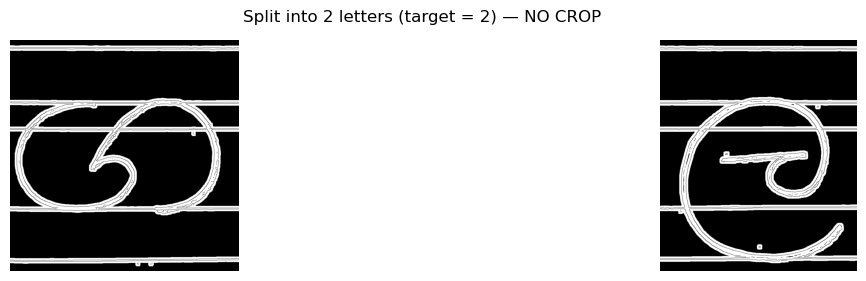

In [6]:
# Preview split (NO CROPPING)
letters = preview_no_crop(clean, num_letters=2)


In [ ]:
# Split the letters and save them in folder
letters = split_word_exact_no_crop(clean, num_letters=2)

save_letters(
    letters,
    base_dir="segmented_letters",
    prefix="char"
)

Saved 2 images to 'segmented_letters'
